<a name="toc_15456_2"></a>
# House price prediction with multiple features


| Size (sqft) | Number of Bedrooms  | Number of floors | Age of  Home | Price (1000s dollars)  |   
| ----------------| ------------------- |----------------- |--------------|-------------- |  
| 2104            | 5                   | 1                | 45           | 460           |  
| 1416            | 3                   | 2                | 40           | 232           |  
| 852             | 2                   | 1                | 35           | 178           |  

Lets build a linear regression model using these values so you can then predict the price for other houses. For example, a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old.  


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# split dataset into features and label
features=np.array([[2104,5,1,45],[1416,3,2,40],[852,2,1,35]])
label=np.array([460,232,178])

For demonstration, $\mathbf{w}$ and $b$ will be loaded with some initial selected values that are near the optimal. 

In [3]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])

# Model Prediction With Multiple Variables
The model's prediction with multiple variables is given by the linear model:

$$ f_{\mathbf{w},b}(\mathbf{x}) =  w_0x_0 + w_1x_1 +... + w_{n-1}x_{n-1} + b \tag{1}$$
or in vector notation:
$$ f_{\mathbf{w},b}(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b  \tag{2} $$ 
where $\cdot$ is a vector `dot product`

# Single Prediction element by element

In [4]:
# Define prediction function
def prediction(w,b,x):
    m=w.shape[0]
    result=0
    for i in range(m):
        result+=x[i]*w[i]
    return result+b
        
# Call the function for one sample
one_sample=features[0]
print(f"Prediction using for loop: {prediction(w_init,b_init,one_sample)} ")

Prediction using for loop: 459.9999976194083 


# Single Prediction, vector

In [5]:
# Define prediction function
def prediction(w,b,x):
    return (np.dot(w,x)+b)
        
# Call the function for one sample
one_sample=features[0]
print(f"Prediction using vectorization: {prediction(w_init,b_init,one_sample)} ")

Prediction using vectorization: 459.9999976194083 


<a name="toc_15456_4"></a>
# Compute Cost With Multiple Variables
The equation for the cost function with multiple variables $J(\mathbf{w},b)$ is:
$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2 \tag{3}$$ 
where:
$$ f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot \mathbf{x}^{(i)} + b  \tag{4} $$ 



In [6]:
def cost_function(w,b,x,y):
    m=label.shape[0]
    cost=0
    for i in range(m):
        cost+=((np.dot(w,x[i])+b)-y[i])**2
    return (cost/(2*m))

print(f"Cost for the initialized parameters:{cost_function(w_init,b_init,features,label)} ")

Cost for the initialized parameters:1.5578904428966628e-12 


<a name="toc_15456_5"></a>
# Gradient Descent With Multiple Variables
Gradient descent for multiple variables:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline\;
& w_j = w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{5}  \; & \text{for j = 0..n-1}\newline
&b\ \ = b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b}  \newline \rbrace
\end{align*}$$

where, n is the number of features, parameters $w_j$,  $b$, are updated simultaneously and where  

$$
\begin{align}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} \tag{6}  \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{7}
\end{align}
$$
* m is the number of training examples in the data set

    
*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target value


In [7]:
# Compute gradient for all weights and bias

def gradient(w,b,x,y):
    bias_gradient=0
    weight_gradient=np.zeros(features.shape[1])
    for i in range(features.shape[0]):
        error=(np.dot(w,x[i])+b)-y[i]
        bias_gradient+=error
        for j in range(features.shape[1]):
            weight_gradient[j] += error*x[i][j]
    return weight_gradient/features.shape[0],bias_gradient/features.shape[0]

In [21]:
# Gradient descent
def gradient_descent(weight,bias,x,y,iteration,learning_rate):
    weight=np.zeros(x.shape[1])
    track_iteration=[]
    track_cost=[]
    for t in range(iteration):
            weight_gradient,bias_gradient=gradient(weight,bias,x,y)
            bias=bias-(learning_rate*bias_gradient)
            weight=weight-(learning_rate*weight_gradient)
            if t%30000==0:
                track_iteration.append(t)
                track_cost.append(cost_function(weight,bias,x,y))
    return weight,bias,track_cost,track_iteration

In [22]:
# Make prediction
weight,bias,track_cost,track_iteration=gradient_descent(0,0,features,label,100000, 5.0e-7)
print(f"Predicted house price:{np.dot(features,weight)+bias}  \nActual Price: {label} ")


Predicted house price:[439.29009262 279.07743103 150.90133274]  
Actual Price: [460 232 178] 


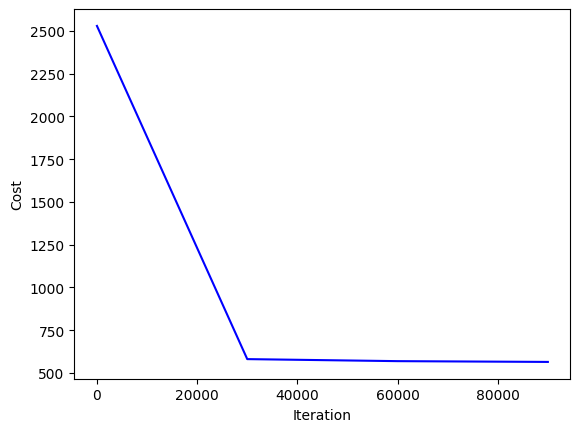

In [23]:
plt.plot(track_iteration,track_cost,c='b')
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

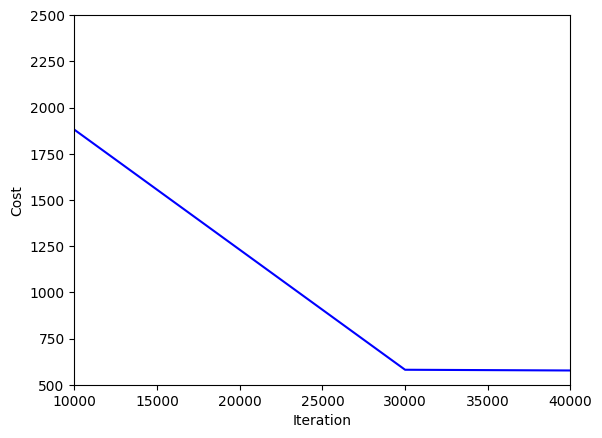

In [24]:
plt.plot(track_iteration,track_cost,c='b')
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.xlim(10000,40000)
plt.ylim(500,2500)
plt.show()